# Employee Attrition Prediction — HR Analytics Project

## What is this project?
Companies lose a lot of money when employees quit.
This project uses real employee data to predict who is likely to leave
and find out why they are leaving.

We will use Python and Machine Learning to answer two questions:
1. WHO is likely to leave?
2. WHY are they leaving?

**Dataset:** IBM HR Analytics Dataset — 1470 employees, 35 columns

## ->Data Loading & Preprocessing

In [2]:
#install dependencies
!pip install pandas numpy scikit-learn matplotlib seaborn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
#checking the data(rows and columns)and printing the first 5 rows of the dataset
df = pd.read_csv(r'hr_raw.csv')
print(df.shape)
df.head()

(1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
#checking for null values in the dataset
print(df.isnull().sum().sum())

0


There are no null or empty values in the dataset.

In [6]:
#checking the distribution of the target variable-taking the count of how many employees left(yes) and how many of them stayed(no).
print(df['Attrition'].value_counts())
print(f"\nAttrition rate: {(df['Attrition']=='Yes').mean()*100:.1f}%")

Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition rate: 16.1%


This means 237 employees left, 1233 stayed. Only 16% left — this is called an imbalanced dataset (more No than Yes).

In [7]:

#Remove useless columns as these columns do not provide us any useful information for our analysis.
df.drop(columns=['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'], inplace=True)

In [8]:

# Encode target:converting the tarrget variable into binary format- yes=1 and no=0
df['Attrition'] = (df['Attrition'] == 'Yes').astype(int)

In [9]:
# Ordinal encoding
df['BusinessTravel'] = df['BusinessTravel'].map({
    'Non-Travel': 0,
    'Travel_Rarely': 1,
    'Travel_Frequently': 2
})

df['OverTime'] = df['OverTime'].map({'No': 0, 'Yes': 1})

These columns have a natural order. Non-Travel < Travel_Rarely < Travel_Frequently. So we give them numbers 0, 1, 2

In [10]:
#Encode nominal columns (columns with NO order):One-hot encoding for nominal columns

nominal_cols = ['Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

print(df.shape)

(1470, 44)


Why? Columns like Department (Sales, R&D, HR) have no order — Sales isn't "bigger" than HR. So we use get_dummies which creates separate Yes/No columns for each category.
After this the shape will become around (1470, 44)

In [11]:
#saving the cleaned dataset into a new csv file called 'hr_clean.csv'
df.to_csv('hr_clean.csv', index=False)
print("Clean file saved!")

Clean file saved!


## ->Exploratory Data Analysis (EDA)

In [12]:
# Load the original raw file for charts
raw = pd.read_csv('hr_raw.csv')

# Add a 0/1 column so we can do math on it
raw['Attrition_bin'] = (raw['Attrition'] == 'Yes').astype(int)

print("Raw data loaded. Shape:", raw.shape)

Raw data loaded. Shape: (1470, 36)


**Why did we load the raw file again for charts?**

In the cleaned file, we converted everything to numbers.
The Attrition column now has 0s and 1s instead of "Yes" and "No".
Also, the Department column no longer exists as one column —
it got split into many columns like Department_Sales, Department_HR.

So we cannot use the cleaned file for charts because:
- The labels would show 0 and 1 instead of "Yes" and "No"
- We cannot group by Department anymore since it no longer exists

The raw file still has all the original text labels intact.
The raw file has Attrition as "Yes" or "No" — we cannot do math on words.
So we added a new column called Attrition_bin with Yes = 1 and No = 0.
Now we can calculate things like:
"What percentage of Sales employees left?"
We simply take the average of 0s and 1s and multiply by 100.


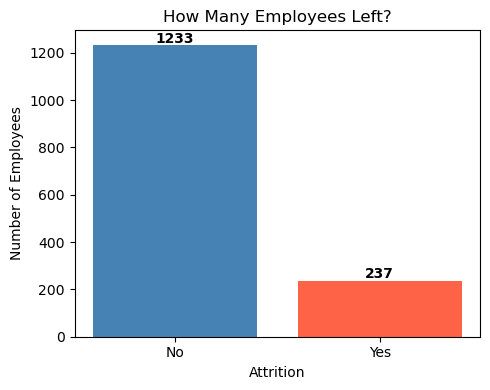

In [14]:
plt.figure(figsize=(5, 4))

counts = raw['Attrition'].value_counts()
plt.bar(counts.index, counts.values, color=['steelblue', 'tomato'])

plt.title("How Many Employees Left?")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

# Add numbers on top of bars
for i, val in enumerate(counts.values):
    plt.text(i, val + 10, str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

**Finding 1 — Overall Attrition Rate**
Only 16% of employees left (237 out of 1470).
The majority stayed. But these 237 departures still costs the company a lot of money.

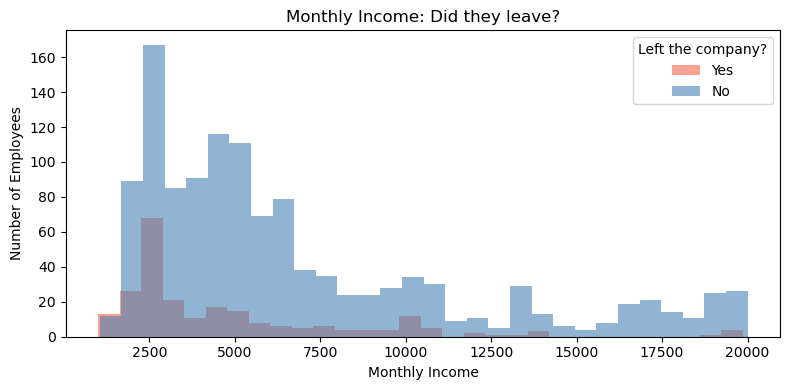

In [15]:
plt.figure(figsize=(8, 4))

for label, color in [('Yes', 'tomato'), ('No', 'steelblue')]:
    data = raw[raw['Attrition'] == label]['MonthlyIncome']
    plt.hist(data, bins=30, alpha=0.6, color=color, label=label)

plt.title("Monthly Income: Did they leave?")
plt.xlabel("Monthly Income")
plt.ylabel("Number of Employees")
plt.legend(title="Left the company?")
plt.tight_layout()
plt.show()

Finding 2 — Low Salary = More Leaving

Looking at this above chart, the red bars (employees who left) are
almost entirely on the LEFT side of the chart.
This means most employees who quit were earning between $2,500 and $5,000 per month.

On the RIGHT side of the chart (salary above $10,000),
there are almost no red bars at all.
This means highly paid employees rarely quit.

Conclusion: Low salary is a strong reason why employees leave.
The company should review and improve compensation,
especially for lower-paid roles like Sales Representatives
and Laboratory Technicians.

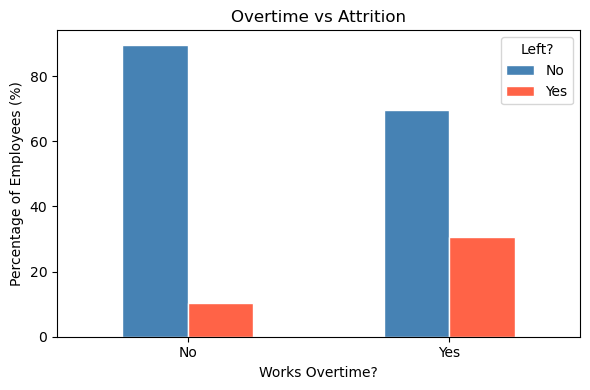

In [16]:
# Calculate % who left for each overtime group
ot = raw.groupby(['OverTime', 'Attrition']).size().unstack(fill_value=0)
ot_pct = ot.div(ot.sum(axis=1), axis=0) * 100

ot_pct.plot(kind='bar', figsize=(6, 4),
            color=['steelblue', 'tomato'],
            edgecolor='white', rot=0)

plt.title("Overtime vs Attrition")
plt.xlabel("Works Overtime?")
plt.ylabel("Percentage of Employees (%)")
plt.legend(title="Left?", labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

Finding 3 — Overtime Causes People to Leave

This chart compares employees who work overtime vs those who don't.

Employees with NO overtime — only about 10% left.
Employees WITH overtime — about 30% left.

This means overtime workers are 3 times more likely to quit.

The reason is burnout. When employees are overworked
for long periods, they get exhausted and eventually resign.

Recommendation: The company should limit overtime hours
and hire more people to share the workload.

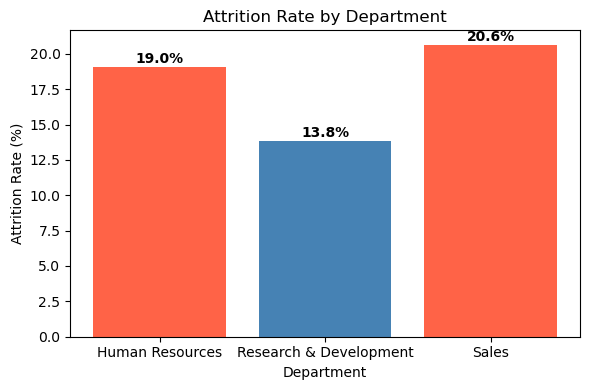

In [17]:
dept = raw.groupby('Department')['Attrition_bin'].mean() * 100

plt.figure(figsize=(6, 4))
bars = plt.bar(dept.index, dept.values,
               color=['tomato' if v > 15 else 'steelblue' for v in dept.values])

# Add % labels on bars
for bar, val in zip(bars, dept.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', fontweight='bold')

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.tight_layout()
plt.show()

Finding 4 — Sales Department is Most Affected
The Sales department has the highest attrition rate at 20.6%.
HR comes second. Research & Development is the most stable department.

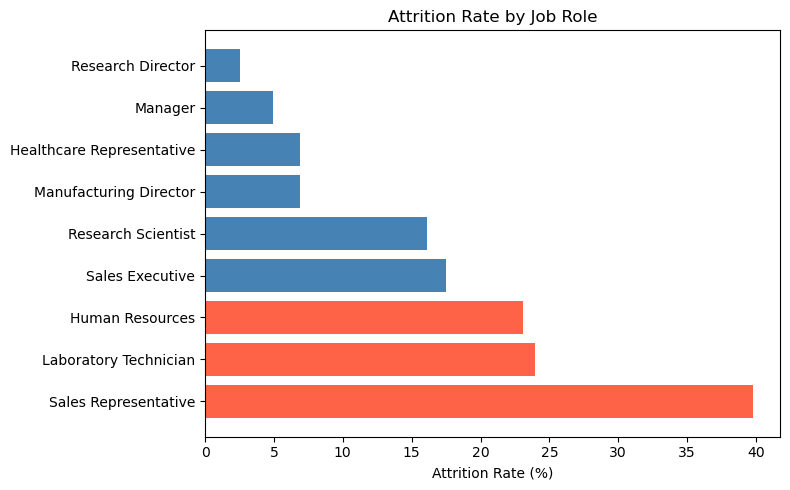

In [18]:
role = raw.groupby('JobRole')['Attrition_bin'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(8, 5))
plt.barh(role.index, role.values,
         color=['tomato' if v > 20 else 'steelblue' for v in role.values])

plt.title("Attrition Rate by Job Role")
plt.xlabel("Attrition Rate (%)")
plt.tight_layout()
plt.show()

Finding 5 — Sales Representatives are Leaving the Most
Sales Representatives have over 40% attrition rate.
This is extremely high and needs urgent attention from HR.
Laboratory Technicians and Human Resources roles are also at risk.

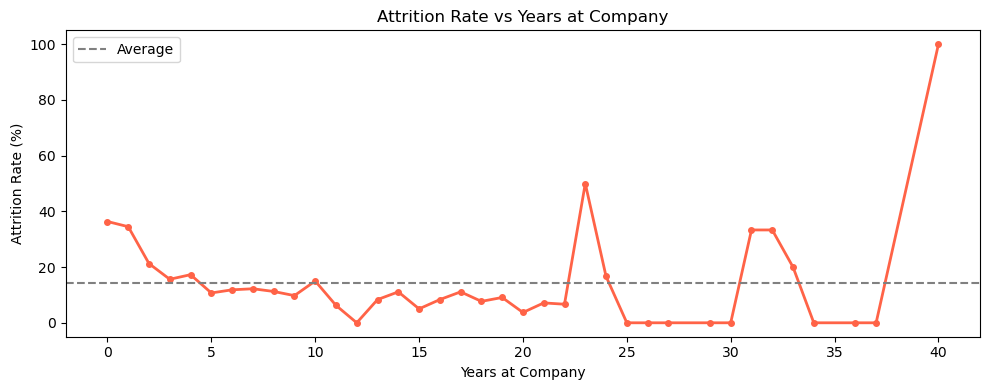

In [19]:
tenure = raw.groupby('YearsAtCompany')['Attrition_bin'].mean() * 100

plt.figure(figsize=(10, 4))
plt.plot(tenure.index, tenure.values, color='tomato', linewidth=2, marker='o', markersize=4)
plt.axhline(tenure.mean(), color='gray', linestyle='--', label='Average')

plt.title("Attrition Rate vs Years at Company")
plt.xlabel("Years at Company")
plt.ylabel("Attrition Rate (%)")
plt.legend()
plt.tight_layout()
plt.show()

Finding 6 — New Employees Leave the Most
Attrition is highest in the first 1 to 2 years of joining.
After year 3, it drops significantly.
This means the company needs better onboarding and support for new hires.

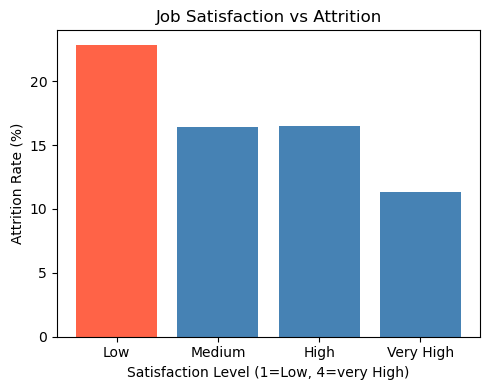

In [20]:
sat = raw.groupby('JobSatisfaction')['Attrition_bin'].mean() * 100

plt.figure(figsize=(5, 4))
plt.bar([1, 2, 3, 4], sat.values,
        color=['tomato' if v == sat.max() else 'steelblue' for v in sat.values])

plt.title("Job Satisfaction vs Attrition")
plt.xlabel("Satisfaction Level (1=Low, 4=very High)")
plt.ylabel("Attrition Rate (%)")
plt.xticks([1, 2, 3, 4], ['Low', 'Medium', 'High', 'Very High'])
plt.tight_layout()
plt.show()

Finding 7 — Unhappy Employees Leave More
Employees with the lowest job satisfaction (Level 1) leave at 23%.
Employees with the highest satisfaction (Level 4) leave at only 11%.
This confirms that keeping employees happy directly reduces attrition.

In [37]:
# Find how each column relates to Attrition
df = pd.read_csv('hr_clean.csv')
corr_with_attrition = df.corr()['Attrition'].sort_values(ascending=False).drop('Attrition')

print("How each factor correlates with Attrition:")
print(corr_with_attrition.head(10))

How each factor correlates with Attrition:
OverTime                           0.246118
MaritalStatus_Single               0.175419
JobRole_Sales Representative       0.157234
BusinessTravel                     0.127006
JobRole_Laboratory Technician      0.098290
Department_Sales                   0.080855
DistanceFromHome                   0.077924
EducationField_Technical Degree    0.069355
EducationField_Marketing           0.055781
NumCompaniesWorked                 0.043494
Name: Attrition, dtype: float64


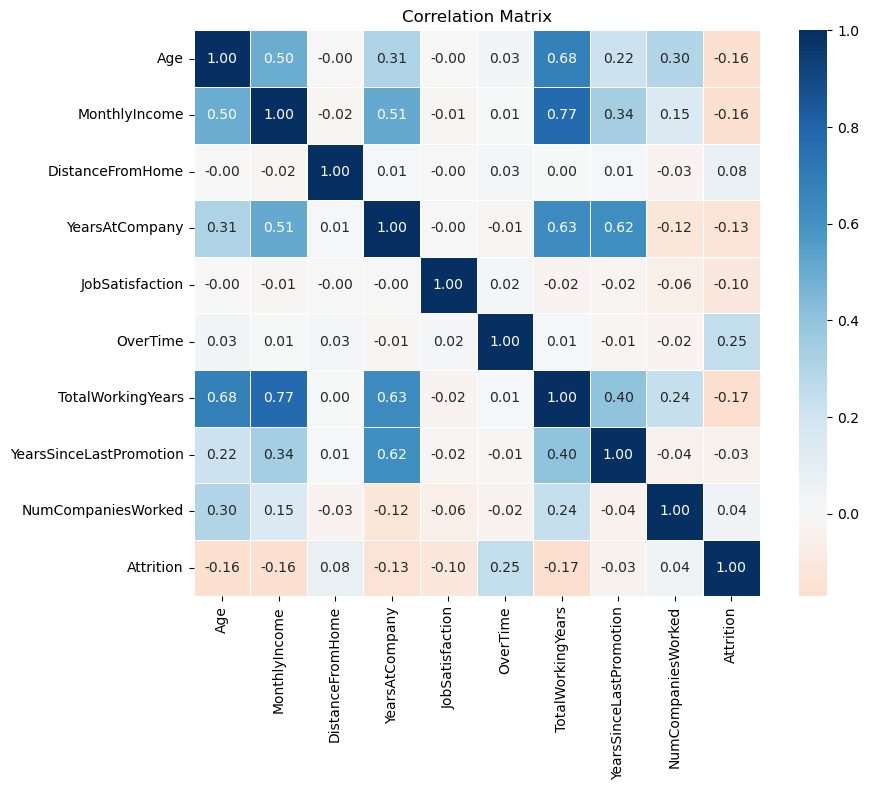

In [ ]:
# Pick only the most important columns 
cols = ['Age', 'MonthlyIncome', 'DistanceFromHome',
        'YearsAtCompany', 'JobSatisfaction', 'OverTime',
        'TotalWorkingYears', 'YearsSinceLastPromotion',
        'NumCompaniesWorked', 'Attrition']

# heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    df[cols].corr(),
    annot=True,
    fmt='.2f',
    cmap='RdBu',
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

Correlation Analysis — What is Related to Attrition?

A correlation matrix shows how strongly each factor
is connected to attrition.

Numbers close to 1.0 = strong positive relationship,
Numbers close to -1.0 = strong negative relationship,
Numbers close to 0.0 = no relationship at all

Key findings from the matrix:

1. OverTime (0.25) — POSITIVE
   Employees who work overtime are more likely to leave.
   This is the strongest positive driver of attrition.

2. MonthlyIncome (-0.16) — NEGATIVE
   Higher salary means less likely to leave.
   Low income pushes employees out.

3. Age (-0.16) — NEGATIVE
   Older employees tend to stay.
   Younger employees are more likely to quit.

4. TotalWorkingYears (-0.17) — NEGATIVE
   More experienced employees stay longer.
   Early career employees are the most at risk.

5. DistanceFromHome (0.08) — NEARLY ZERO
   Distance from home has almost no effect on attrition.
   Employees do not leave just because they live far away.

6. JobSatisfaction (-0.10) — NEGATIVE
   Less satisfied employees leave more.
   But the effect is moderate, not very strong alone.

Overall Conclusion:
The biggest drivers of attrition are Overtime and low salary.
Distance from home is NOT a significant factor.

## ->Building the Prediction Model

Now we build a Machine Learning model that can predict
whether a new employee is likely to leave or stay.

This is a Classification problem — the answer is either Yes (1) or No (0).

We will train two models:
1. Logistic Regression — simple and easy to explain
2. Random Forest — more powerful, uses many decision trees together

We split our data:
- 80% is given to the model to learn from (training data)
- 20% is kept hidden to test how well the model learned (testing data)

In [21]:
# Load the cleaned file we saved 
df = pd.read_csv('hr_clean.csv')

# X = all columns EXCEPT Attrition (these are inputs)
X = df.drop('Attrition', axis=1)

# y = only the Attrition column (this is what we want to predict-Target variable )
y = df['Attrition']

print("Input(Train) shape:", X.shape)
print("Target(Test) shape:", y.shape)

Input(Train) shape: (1470, 43)
Target(Test) shape: (1470,)


In [22]:
from sklearn.model_selection import train_test_split

# 80% for training, 20% for testing
# stratify=y means keep same Yes/No ratio in both splits
# random_state=42 means you get same result every time you run
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 1176
Testing rows: 294


In [23]:
from sklearn.preprocessing import StandardScaler

# StandardScaler makes all numbers on same scale
# Example: Income is in thousands, Age is in tens
# Logistic Regression gets confused by this difference
# Scaling fixes it
scaler = StandardScaler()

# Fit on training data and transform it
X_train_sc = scaler.fit_transform(X_train)

# ONLY transform test data, never fit on it
# (fitting on test data = cheating!)
X_test_sc = scaler.transform(X_test)

print("Scaling done!")

Scaling done!


In [24]:
from sklearn.linear_model import LogisticRegression

# class_weight='balanced' handles the imbalance
# (remember only 16% left, 84% stayed)
lr = LogisticRegression(class_weight='balanced',
                        max_iter=1000,
                        random_state=42)

# Train the model
lr.fit(X_train_sc, y_train)

# Predict on test data
y_pred_lr = lr.predict(X_test_sc)

print("Logistic Regression trained!")

Logistic Regression trained!


In [25]:
from sklearn.metrics import classification_report

print("=== Logistic Regression Results ===")
print(classification_report(y_test, y_pred_lr))

=== Logistic Regression Results ===
              precision    recall  f1-score   support

           0       0.92      0.79      0.85       247
           1       0.37      0.66      0.47        47

    accuracy                           0.77       294
   macro avg       0.65      0.72      0.66       294
weighted avg       0.84      0.77      0.79       294



In [26]:
from sklearn.ensemble import RandomForestClassifier

# n_estimators=200 means build 200 decision trees
# class_weight='balanced' handles imbalance
rf = RandomForestClassifier(n_estimators=200,
                             class_weight='balanced',
                             random_state=42,
                             n_jobs=-1)

# Random Forest doesn't need scaled data
rf.fit(X_train, y_train)

# Predict on test data
y_pred_rf = rf.predict(X_test)

print("Random Forest trained!")

Random Forest trained!


In [27]:
print("=== Random Forest Results ===")
print(classification_report(y_test, y_pred_rf))

=== Random Forest Results ===
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.50      0.09      0.15        47

    accuracy                           0.84       294
   macro avg       0.67      0.53      0.53       294
weighted avg       0.79      0.84      0.79       294



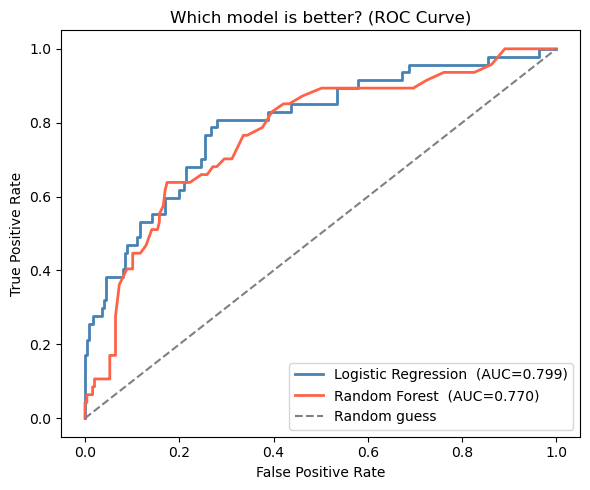

In [28]:
from sklearn.metrics import roc_auc_score, roc_curve

# Get probability scores for both models
y_prob_lr = lr.predict_proba(X_test_sc)[:, 1]
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# Plot ROC curves
plt.figure(figsize=(6, 5))

for y_prob, label, color in [
    (y_prob_lr, 'Logistic Regression', 'steelblue'),
    (y_prob_rf, 'Random Forest', 'tomato')
]:
    auc = roc_auc_score(y_test, y_prob)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{label}  (AUC={auc:.3f})')

# Random baseline
plt.plot([0, 1], [0, 1], '--', color='gray', label='Random guess')

plt.title("Which model is better? (ROC Curve)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

Model Results — Which is Better?

Logistic Regression:
- Accuracy: 77%
- Recall for leavers: 66% — catches 66 out of every 100 people who will leave

Random Forest:
- Accuracy: 84%
- Recall for leavers: 9% — only catches 9 out of every 100 people who will leave

Even though Random Forest has higher accuracy, Logistic Regression is better
for our use case because it catches more actual leavers.

In HR, missing someone who is about to quit is very expensive.
So Recall (catching leavers) matters more than overall Accuracy.

So winner: Logistic Regression.

In [29]:
import pickle

# Save the Random Forest model to a file
with open("rf_attrition_model.pkl", "wb") as f:
    pickle.dump(rf, f)

# Save the scaler too
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Model saved successfully!")

Model saved successfully!


## ->Insights and At-Risk Employee List

Now we extract the most important findings from our model.

Feature Importance tells us which factors matter most
in predicting whether someone will leave.

We also create a Watch List — a list of employees who have
a high probability of leaving right now.
HR can use this list to take action before it is too late.

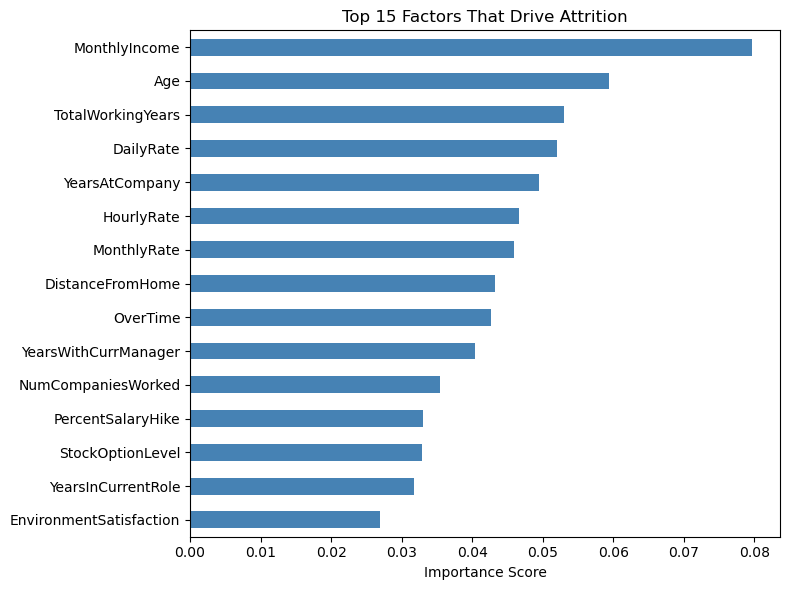

Top 3 Drivers of Attrition:
  1. MonthlyIncome  →  0.0797
  2. Age  →  0.0594
  3. TotalWorkingYears  →  0.0530


In [30]:
# Get importance of each feature from Random Forest
importances = pd.Series(rf.feature_importances_, index=X.columns)

# Pick top 15 most important
top15 = importances.nlargest(15).sort_values()

# Plot it
plt.figure(figsize=(8, 6))
top15.plot(kind='barh', color='steelblue')

plt.title("Top 15 Factors That Drive Attrition")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

# Print top 3
print("Top 3 Drivers of Attrition:")
for i, (feat, score) in enumerate(importances.nlargest(3).items(), 1):
    print(f"  {i}. {feat}  →  {score:.4f}")

In [31]:
# Predict probability of leaving for ALL 1470 employees
risk_scores = rf.predict_proba(X)[:, 1]

# Load raw file to get readable info like department and job role
raw2 = pd.read_csv(r'hr_raw.csv')

# Build a table with employee info + their risk score
watch_list = pd.DataFrame({
    'Age':            raw2['Age'].values,
    'Department':     raw2['Department'].values,
    'JobRole':        raw2['JobRole'].values,
    'MonthlyIncome':  raw2['MonthlyIncome'].values,
    'YearsAtCompany': raw2['YearsAtCompany'].values,
    'RiskScore_%':    (risk_scores * 100).round(1)
})

# Keep only HIGH RISK employees (above 70% chance of leaving)
high_risk = watch_list[watch_list['RiskScore_%'] >= 70].sort_values(
    'RiskScore_%', ascending=False).reset_index(drop=True)

print(f"Total high-risk employees: {len(high_risk)}")
print(high_risk.head(10))

Total high-risk employees: 139
   Age              Department                JobRole  MonthlyIncome  \
0   26  Research & Development  Laboratory Technician           2340   
1   29  Research & Development     Research Scientist           2439   
2   19                   Sales   Sales Representative           1675   
3   31                   Sales   Sales Representative           1359   
4   29                   Sales   Sales Representative           1091   
5   18                   Sales   Sales Representative           1569   
6   23                   Sales   Sales Representative           1790   
7   18                   Sales   Sales Representative           1878   
8   27         Human Resources        Human Resources           2863   
9   28  Research & Development  Laboratory Technician           2408   

   YearsAtCompany  RiskScore_%  
0               1         93.5  
1               1         91.5  
2               0         90.5  
3               1         90.5  
4          

In [32]:
high_risk.to_csv('at_risk_employees.csv', index=False)
print("Watch list saved as 'at_risk_employees.csv'")

Watch list saved as 'at_risk_employees.csv'


## ->Conclusion and Recommendations

After analyzing data from 1470 employees, our model found these key insights:

1. Low salary is the biggest reason employees leave.
2. Overtime causes burnout and leads to resignation.
3. New employees (year 1-2) are the most vulnerable group.
4. Sales Representatives have the highest attrition rate at 40%+.
5. Low job satisfaction strongly predicts leaving.

Our model (Logistic Regression) can predict potential leavers
with 66% recall — meaning it catches 2 out of every 3 people
who are actually about to leave.

139 employees have been flagged as high-risk (above 70% probability).
HR should schedule stay interviews with these employees immediately.



## ->HR_Attrition_Report.docx

In [1]:
pip install python-docx

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from docx import Document
from docx.shared import Pt, RGBColor
from docx.enum.text import WD_ALIGN_PARAGRAPH

# Create a new Word document
doc = Document()

# ── TITLE ──────────────────────────────────────────
title = doc.add_heading('Employee Attrition Analysis Report', 0)
title.alignment = WD_ALIGN_PARAGRAPH.CENTER

subtitle = doc.add_paragraph('HR Analytics Project — IBM Dataset — 1,470 Employees')
subtitle.alignment = WD_ALIGN_PARAGRAPH.CENTER

doc.add_paragraph('─' * 60)

# ── SECTION 1 — OVERVIEW ───────────────────────────
doc.add_heading('1. What is this Report About?', level=1)

doc.add_paragraph(
    'This report summarizes the findings from a machine learning '
    'analysis done on data from 1,470 employees. '
    'The goal was to find out why employees are leaving '
    'and predict who is likely to leave next.'
)

doc.add_paragraph(
    'Out of 1,470 employees, 237 left the company. '
    'That is a 16% attrition rate. '
    'Every time someone leaves, the company spends a lot of money '
    'finding and training a replacement. '
    'This report helps HR take action before people quit.'
)

# Key numbers table
doc.add_heading('Key Numbers at a Glance', level=2)
table1 = doc.add_table(rows=2, cols=4)
table1.style = 'Table Grid'

# Header row
headers = ['Total Employees', 'Employees Who Left',
           'Attrition Rate', 'Estimated Cost']
for i, header in enumerate(headers):
    cell = table1.rows[0].cells[i]
    cell.text = header
    cell.paragraphs[0].runs[0].bold = True

# Data row
values = ['1,470', '237', '16.1%', '$4.7 Million+']
for i, value in enumerate(values):
    table1.rows[1].cells[i].text = value

doc.add_paragraph('')

# ── SECTION 2 — TOP 3 REASONS ──────────────────────
doc.add_heading('2. Top 3 Reasons Why Employees Leave', level=1)

doc.add_paragraph(
    'Our machine learning model looked at all employee data '
    'and found these three factors matter the most:'
)

# Reason 1
doc.add_heading('Reason 1 — Low Monthly Income', level=2)
doc.add_paragraph(
    'Employees earning lower salaries are much more likely to quit. '
    'People who left were earning on average 43% less '
    'than people who stayed. '
    'Low pay is the single biggest driver of attrition.'
)
doc.add_paragraph('Action: Review salaries, especially for Sales Representatives '
                  'and Laboratory Technicians.')

# Reason 2
doc.add_heading('Reason 2 — Age and Career Stage', level=2)
doc.add_paragraph(
    'Younger employees and those who are new to the company '
    'leave the most. Employees in their first 1 to 2 years '
    'are the most at risk of leaving. '
    'They are still exploring their options and looking for growth.'
)
doc.add_paragraph('Action: Improve onboarding. Assign a mentor to every new hire. '
                  'Set clear goals for the first 6 months.')

# Reason 3
doc.add_heading('Reason 3 — Overtime and Burnout', level=2)
doc.add_paragraph(
    'Employees who work overtime leave at 3 times the rate '
    'of employees who do not work overtime. '
    'Overworked employees get burnt out and eventually resign.'
)
doc.add_paragraph('Action: Limit overtime hours. Redistribute work fairly '
                  'across the team. Hire more staff if needed.')

doc.add_paragraph('')

# ── SECTION 3 — DEPARTMENT BREAKDOWN ───────────────
doc.add_heading('3. Which Departments are Most Affected?', level=1)

table2 = doc.add_table(rows=4, cols=4)
table2.style = 'Table Grid'

dept_headers = ['Department', 'Attrition Rate', 'Risk Level', 'What to Do']
for i, h in enumerate(dept_headers):
    cell = table2.rows[0].cells[i]
    cell.text = h
    cell.paragraphs[0].runs[0].bold = True

dept_data = [
    ['Sales',                  '20.6%', 'HIGH',   'Immediate Action Needed'],
    ['Human Resources',        '19.0%', 'HIGH',   'Immediate Action Needed'],
    ['Research & Development', '13.8%', 'MEDIUM', 'Monitor Closely'],
]
for row_idx, row_data in enumerate(dept_data, start=1):
    for col_idx, value in enumerate(row_data):
        table2.rows[row_idx].cells[col_idx].text = value

doc.add_paragraph('')

# ── SECTION 4 — OTHER FINDINGS ─────────────────────
doc.add_heading('4. Other Important Findings', level=1)

findings = [
    ('Sales Representatives have 40%+ attrition',
     'This is the highest of any job role in the company. '
     'It needs urgent attention. Review their targets, '
     'workload, and pay immediately.'),

    ('Attrition spikes in years 1 and 2',
     'New employees are the most vulnerable. '
     'After year 3, most employees tend to stay. '
     'The first two years are the most critical period.'),

    ('Low job satisfaction predicts leaving',
     'Employees who rated their job satisfaction as Low (Level 1) '
     'leave at 23%. Those with Very High satisfaction leave at only 11%. '
     'Regular satisfaction surveys can help catch unhappy employees early.'),
]

for title, body in findings:
    doc.add_heading(title, level=2)
    doc.add_paragraph(body)

doc.add_paragraph('')

# ── SECTION 5 — RECOMMENDATIONS ────────────────────
doc.add_heading('5. Our Recommendations for HR', level=1)

recs = [
    ('1. Review Salaries Immediately',
     'Low income is the biggest reason people leave. '
     'Do a salary benchmarking exercise and adjust pay '
     'for underpaid employees, especially in Sales.'),

    ('2. Reduce Overtime',
     'Overtime workers leave 3x more. '
     'Set a maximum overtime limit and give comp-off days '
     'to employees who work extra hours.'),

    ('3. Fix the First Two Years',
     'Launch a proper onboarding program. '
     'Assign mentors to new hires. '
     'Do a 3-month and 6-month check-in with every new employee.'),

    ('4. Focus on Sales Team Urgently',
     'Sales Representatives are leaving at 40%+. '
     'Hold focus group meetings with the Sales team. '
     'Review their targets, pressure, and compensation.'),

    ('5. Schedule Stay Interviews Now',
     '139 employees have been flagged as high risk — '
     'above 70% probability of leaving. '
     'HR should call each of them for a one-on-one conversation '
     'within the next 30 days.'),
]

for rec_title, rec_body in recs:
    doc.add_heading(rec_title, level=2)
    doc.add_paragraph(rec_body)

doc.add_paragraph('')

# ── SECTION 6 — MODEL PERFORMANCE 
doc.add_heading('6. How Good is Our Prediction Model?', level=1)

doc.add_paragraph(
    'We trained two machine learning models and compared them.'
)

table3 = doc.add_table(rows=3, cols=4)
table3.style = 'Table Grid'

model_headers = ['Model', 'Accuracy', 'Recall (Catching Leavers)', 'Winner?']
for i, h in enumerate(model_headers):
    cell = table3.rows[0].cells[i]
    cell.text = h
    cell.paragraphs[0].runs[0].bold = True

model_data = [
    ['Logistic Regression', '77%', '66% — catches 2 in 3 leavers', 'YES'],
    ['Random Forest',       '84%', '9%  — misses most leavers',    'NO'],
]
for row_idx, row_data in enumerate(model_data, start=1):
    for col_idx, value in enumerate(row_data):
        table3.rows[row_idx].cells[col_idx].text = value

doc.add_paragraph('')
doc.add_paragraph(
    'Even though Random Forest has higher accuracy, '
    'Logistic Regression is better for HR because it catches '
    'more actual leavers. Missing someone who is about to quit '
    'is very expensive. So catching leavers (Recall) '
    'matters more than overall accuracy.'
)

doc.add_paragraph('')

# CONCLUSION
doc.add_heading('Conclusion', level=1)
doc.add_paragraph(
    'Our analysis shows that attrition is not random. '
    'It is driven by specific, fixable problems — '
    'low pay, overwork, poor onboarding, and lack of career growth. '
    'By acting on the recommendations in this report, '
    'HR can significantly reduce employee turnover '
    'and save the company millions of dollars every year.'
)

doc.add_paragraph('─' * 60)
doc.add_paragraph(
    'This report was created using Machine Learning on the '
    'IBM HR Analytics Dataset. '
    'Analysis done using Python, Scikit-Learn, and Pandas.'
    'Predictions are probabilistic and should be used alongside human judgment by HR professionals'
)

# SAVE THE FILE 
doc.save('HR_Attrition_Report.docx')
print("Word document saved as HR_Attrition_Report.docx")

Word document saved as HR_Attrition_Report.docx
